# Case Study: Bellabeat Smart Device Usage Analysis


**Author:** Hoang Do Phan
**Date:** May 2026


***


## Bellabeat: How Can a Wellness Technology Company Play It Smart?


# STEP 1: ASK


### 1.1 Background


This project is the second case study from the [Google Data Analytics Professional Certificate](https://www.coursera.org/professional-certificates/google-data-analytics) program.


The analysis focuses on Bellabeat, a wellness technology company that develops smart products designed to help women monitor and improve their health.

As part of this case study, the goal is to analyze Fitbit smart device usage data to better understand consumer behavior and identify trends that can support Bellabeat's future marketing strategy and business growth.


### 1.2 Business Task


Analyze Fitbit smart device usage data to identify user behavior trends and generate marketing recommendations for Bellabeat.


### 1.3 Business Objectives


1. What trends can be identified from smart device usage data?
2. How could these trends apply to Bellabeat customers?
3. How could these insights influence Bellabeat's marketing strategy?

### 1.4 Deliverables


1. A clear summary of the business task
2. A description of the data source used
3. Documentation of data cleaning and manipulation
4. A summary of the analysis
5. Supporting visualizations and key findings
6. High-level recommendations based on the analysis

### 1.5 Key Stakeholders


1. Urška Sršen – Bellabeat Co-founder and Chief Creative Officer
2. Sando Mur – Bellabeat Co-founder and Executive Team Member
3. Bellabeat Marketing Analytics Team


***


# STEP 2: PREPARE


### 2.1 Information on Data Source


1. The data is publicly available on Kaggle: [Fitbit Fitness Tracker Data](https://www.kaggle.com/datasets/arashnic/fitbit).
2. The dataset was generated by respondents from a distributed survey conducted through Amazon Mechanical Turk between 12 March 2016 and 12 May 2016.
3. The dataset contains fitness tracking information from 30 Fitbit users who consented to the submission of their personal tracker data.
4. Data collected includes:
   - Physical activity recorded in minutes
   - Daily step counts
   - Calories burned
   - Activity intensity levels
   - Sleep monitoring data
   - Heart rate tracking information


### 2.2 Data Selection


This project utilizes 11 Fitbit datasets from the **Fitabase Data 3.12.16–4.11.16** folder.

Selected files include:


```text
dailyActivity_merged.csv
dailyCalories_merged.csv
dailyIntensities_merged.csv
dailySteps_merged.csv
sleepDay_merged.csv


hourlyCalories_merged.csv
hourlyIntensities_merged.csv
hourlySteps_merged.csv


minuteCaloriesNarrow_merged.csv
minuteIntensitiesNarrow_merged.csv
minuteStepsNarrow_merged.csv
```


These datasets contain daily, hourly, and minute-level activity data that support the analysis of user activity patterns, calorie expenditure, and sleep behavior.

### 2.3 Limitations of the Dataset


1. The dataset contains data from only 30 Fitbit users, which may not be representative of the broader population.
2. The data was collected in 2016 and may not fully reflect current consumer behavior and smart device usage trends.
3. The dataset originates from a third-party source, making it difficult to verify the accuracy of self-reported information.
4. Fitbit users may not accurately represent Bellabeat's target customer segment.


### 2.4 Is the Data ROCCC?


A good data source should be ROCCC: **Reliable, Original, Comprehensive, Current, and Cited.**


| Criteria | Evaluation |
|-----------|------------|
| Reliable | Low – Sample size of only 30 users |
| Original | Low – Data collected through Amazon Mechanical Turk |
| Comprehensive | Medium – Contains activity, sleep, calorie, and fitness metrics |
| Current | Low – Data was collected in 2016 |
| Cited | Medium – Publicly available and documented through Kaggle |


Overall, the dataset has several limitations but remains suitable for educational purposes and exploratory data analysis.






***


# STEP 3: PROCESS

Python was used to clean and prepare the Fitbit datasets for analysis.

### 3.1 Import Libraries

The following libraries were used throughout this project:

- NumPy
- Pandas
- Matplotlib
- Seaborn
- Datetime

In [ ]:
# Import libraries

import numpy as np          # numerical computing
import pandas as pd         # data manipulation and analysis
import matplotlib.pyplot as plt   # data visualization
import seaborn as sns       # statistical visualization
import datetime as dt       # date and time processing

### 3.2 Load Datasets

The Fitbit datasets were imported into Python for cleaning and analysis. This project utilizes 11 datasets containing daily, hourly, and minute-level activity information.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dailyActivity_merged.csv to dailyActivity_merged (1).csv
Saving heartrate_seconds_merged.csv to heartrate_seconds_merged.csv
Saving hourlyCalories_merged.csv to hourlyCalories_merged (1).csv
Saving hourlyIntensities_merged.csv to hourlyIntensities_merged (1).csv
Saving hourlySteps_merged.csv to hourlySteps_merged (1).csv
Saving minuteCaloriesNarrow_merged.csv to minuteCaloriesNarrow_merged.csv
Saving minuteIntensitiesNarrow_merged.csv to minuteIntensitiesNarrow_merged.csv
Saving minuteMETsNarrow_merged.csv to minuteMETsNarrow_merged.csv
Saving minuteSleep_merged.csv to minuteSleep_merged.csv
Saving minuteStepsNarrow_merged.csv to minuteStepsNarrow_merged.csv
Saving weightLogInfo_merged.csv to weightLogInfo_merged (2).csv


### 3.3 Check Uploaded Files

The uploaded files were verified to ensure that all required datasets were available in the working directory.

In [ ]:
# Display all files currently available

import os

os.listdir()


['.config',
 'weightLogInfo_merged (1).csv',
 'heartrate_seconds_merged.csv.zip',
 'minuteCaloriesNarrow_merged.csv.zip',
 'dailyActivity_merged.csv',
 'cb=gapi.loaded_0',
 'weightLogInfo_merged (2).csv',
 'minuteSleep_merged.csv',
 'minuteMETsNarrow_merged.csv',
 'minuteIntensitiesNarrow_merged.csv',
 'minuteStepsNarrow_merged.csv',
 'minuteIntensitiesNarrow_merged.csv.zip',
 'hourlySteps_merged (1).csv',
 'hourlyIntensities_merged (1).csv',
 'minuteCaloriesNarrow_merged.csv',
 'hourlySteps_merged.csv',
 'hourlyIntensities_merged.csv',
 'minuteSleep_merged.csv.zip',
 'hourlyCalories_merged (1).csv',
 'minuteMETsNarrow_merged.csv.zip',
 'minuteStepsNarrow_merged.csv.zip',
 'hourlyCalories_merged.csv',
 'weightLogInfo_merged.csv',
 'heartrate_seconds_merged.csv',
 'dailyActivity_merged (1).csv',
 'sample_data']

### 3.4 Load the Primary Dataset

The daily activity dataset was selected as the primary dataset because it contains key information about user activity, distance, and calories burned.

In [ ]:
# Load the primary daily activity dataset

daily_activity = pd.read_csv("dailyActivity_merged.csv")

### 3.5 Preview the Dataset

The first few rows were displayed to better understand the structure and contents of the dataset.

In [ ]:
# Preview the first five rows

daily_activity.head(10)

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819
1,1503960366,3/26/2016,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154
2,1503960366,3/27/2016,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944
3,1503960366,3/28/2016,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932
4,1503960366,3/29/2016,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886
5,1503960366,3/30/2016,10970,7.16,7.16,0.0,2.36,0.51,4.29,0.0,30,13,223,1174,1820
6,1503960366,3/31/2016,12256,7.86,7.86,0.0,2.29,0.49,5.04,0.0,33,12,239,820,1889
7,1503960366,4/1/2016,12262,7.87,7.87,0.0,3.32,0.83,3.64,0.0,47,21,200,866,1868
8,1503960366,4/2/2016,11248,7.25,7.25,0.0,3.00,0.45,3.74,0.0,40,11,244,636,1843
9,1503960366,4/3/2016,10016,6.37,6.37,0.0,0.91,1.28,4.18,0.0,15,30,314,655,1850


### 3.6 Check Dataset Size

The number of rows and columns was checked to understand the size of the dataset.


In [ ]:
daily_activity.shape

(457, 15)

The daily activity dataset contains 457 records and 15 variables related to user activity, distance traveled, activity intensity, and calories burned.

### 3.7 Check Dataset Information

The dataset information was reviewed to examine column names, data types, and non-null values.

In [ ]:
# Display dataset information

daily_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        457 non-null    int64  
 1   ActivityDate              457 non-null    object 
 2   TotalSteps                457 non-null    int64  
 3   TotalDistance             457 non-null    float64
 4   TrackerDistance           457 non-null    float64
 5   LoggedActivitiesDistance  457 non-null    float64
 6   VeryActiveDistance        457 non-null    float64
 7   ModeratelyActiveDistance  457 non-null    float64
 8   LightActiveDistance       457 non-null    float64
 9   SedentaryActiveDistance   457 non-null    float64
 10  VeryActiveMinutes         457 non-null    int64  
 11  FairlyActiveMinutes       457 non-null    int64  
 12  LightlyActiveMinutes      457 non-null    int64  
 13  SedentaryMinutes          457 non-null    int64  
 14  Calories  

The daily activity dataset contains 457 records and 15 variables. All columns contain 457 non-null values, indicating that there are no missing values in the dataset. The dataset includes activity metrics such as steps, distance, activity intensity, sedentary behavior, and calories burned.

### 3.8 Check Missing Values

Missing values were examined to ensure the completeness and quality of the dataset.

In [ ]:
# Check for missing values in each column

missing_values_count = daily_activity.isnull().sum()

missing_values_count

,0
Id,0
ActivityDate,0
TotalSteps,0
TotalDistance,0
TrackerDistance,0
LoggedActivitiesDistance,0
VeryActiveDistance,0
ModeratelyActiveDistance,0
LightActiveDistance,0
SedentaryActiveDistance,0


No missing values were found in the daily activity dataset !!!

### 3.9 Check Duplicate Records

Duplicate records were examined to avoid inaccurate analysis results.

In [ ]:
# Check for duplicate records

daily_activity.duplicated().sum()

np.int64(0)

No duplicate records were found in the daily activity dataset too !!!

### 3.10 Feature Engineering

Additional variables were created to support further analysis. A new column named `DayOfTheWeek` was generated from the activity date to identify weekly activity patterns.

In [ ]:
# Convert ActivityDate to datetime format

daily_activity["ActivityDate"] = pd.to_datetime(
    daily_activity["ActivityDate"]
)

# Create day of week column

daily_activity["DayOfTheWeek"] = (
    daily_activity["ActivityDate"].dt.day_name()
)

# Create month column

daily_activity["Month"] = (
    daily_activity["ActivityDate"].dt.month_name()
)

# Preview transformed columns

daily_activity[
    ["ActivityDate", "DayOfTheWeek", "Month"]
].head()

,ActivityDate,DayOfTheWeek,Month
0,2016-03-25,Friday,March
1,2016-03-26,Saturday,March
2,2016-03-27,Sunday,March
3,2016-03-28,Monday,March
4,2016-03-29,Tuesday,March


### 3.11 Rearrange Columns

The dataset columns were reorganized to improve readability and facilitate further analysis.

In [ ]:
# Rename columns

daily_activity.rename(
    columns={
        "Id": "id",
        "ActivityDate": "date",
        "DayOfTheWeek": "day_of_the_week",
        "TotalSteps": "total_steps",
        "TotalDistance": "total_distance",
        "TrackerDistance": "tracker_distance",
        "LoggedActivitiesDistance": "logged_activities_distance",
        "VeryActiveDistance": "very_active_distance",
        "ModeratelyActiveDistance": "moderately_active_distance",
        "LightActiveDistance": "light_active_distance",
        "SedentaryActiveDistance": "sedentary_active_distance",
        "VeryActiveMinutes": "very_active_minutes",
        "FairlyActiveMinutes": "fairly_active_minutes",
        "LightlyActiveMinutes": "lightly_active_minutes",
        "SedentaryMinutes": "sedentary_minutes",
        "Calories": "calories"
    },
    inplace=True
)

In [ ]:
# Display updated column names

print(daily_activity.columns.tolist())

['id', 'date', 'total_steps', 'total_distance', 'tracker_distance', 'logged_activities_distance', 'very_active_distance', 'moderately_active_distance', 'light_active_distance', 'sedentary_active_distance', 'very_active_minutes', 'fairly_active_minutes', 'lightly_active_minutes', 'sedentary_minutes', 'calories', 'day_of_the_week', 'Month']


In [ ]:
# Preview the cleaned dataset

daily_activity.head()

,id,date,total_steps,total_distance,tracker_distance,logged_activities_distance,very_active_distance,moderately_active_distance,light_active_distance,sedentary_active_distance,very_active_minutes,fairly_active_minutes,lightly_active_minutes,sedentary_minutes,calories,day_of_the_week,Month
0,1503960366,2016-03-25,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819,Friday,March
1,1503960366,2016-03-26,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154,Saturday,March
2,1503960366,2016-03-27,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944,Sunday,March
3,1503960366,2016-03-28,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932,Monday,March
4,1503960366,2016-03-29,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886,Tuesday,March


***
# STEP 4: ANALYZE

In this step, the dataset is analyzed to identify user activity patterns, daily behavior trends, and relationships between key fitness metrics.

### 4.1 Summary Statistics

Descriptive statistics were reviewed to gain a general understanding of user activity levels including: count,mean,min,25%,50%,75%,max.std.

In [23]:
daily_activity.describe()

,id,date,total_steps,total_distance,tracker_distance,logged_activities_distance,very_active_distance,moderately_active_distance,light_active_distance,sedentary_active_distance,very_active_minutes,fairly_active_minutes,lightly_active_minutes,sedentary_minutes,calories
count,4.570000e+02,457,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000
mean,4.628595e+09,2016-04-04 04:40:26.258205696,6546.562363,4.663523,4.609847,0.179427,1.180897,0.478643,2.890197,0.001904,16.623632,13.070022,170.070022,995.282276,2189.452954
min,1.503960e+09,2016-03-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,32.000000,0.000000
25%,2.347168e+09,2016-04-02 00:00:00,1988.000000,1.410000,1.280000,0.000000,0.000000,0.000000,0.870000,0.000000,0.000000,0.000000,64.000000,728.000000,1776.000000
50%,4.057193e+09,2016-04-05 00:00:00,5986.000000,4.090000,4.090000,0.000000,0.000000,0.020000,2.930000,0.000000,0.000000,1.000000,181.000000,1057.000000,2062.000000
75%,6.391747e+09,2016-04-08 00:00:00,10198.000000,7.160000,7.110000,0.000000,1.310000,0.670000,4.460000,0.000000,25.000000,16.000000,257.000000,1285.000000,2667.000000
max,8.877689e+09,2016-04-12 00:00:00,28497.000000,27.530001,27.530001,6.727057,21.920000,6.400000,12.510000,0.100000,202.000000,660.000000,720.000000,1440.000000,4562.000000
std,2.293781e+09,NaN,5398.493064,4.082072,4.068540,0.849232,2.487159,0.830995,2.237523,0.008487,28.919704,36.208635,122.205372,337.021404,815.484523


The summary statistics indicate that Fitbit users recorded an average of 6,547 steps and burned approximately 2,189 calories per day. Users also spent a significant amount of time being sedentary, averaging 995 minutes daily. Overall, the data suggests moderate activity levels with opportunities for increased physical activity.

### 4.2 Daily Steps Analysis

The average number of daily steps was calculated to evaluate overall activity levels among Fitbit users.

In [26]:
round(daily_activity["total_steps"].mean(), 2)

np.float64(6546.56)

### 4.3 Calories Burned Analysis

The average number of calories burned per day was analyzed to understand users' energy expenditure.

In [28]:
round(daily_activity["calories"].mean(),2)

np.float64(2189.45)

### 4.4 Active Minutes Analysis

The average amount of active minutes was calculated by combining very active, fairly active, and lightly active minutes.

In [32]:
daily_activity["total_active_minutes"]= (
    daily_activity["very_active_minutes"]
    + daily_activity["fairly_active_minutes"]
    + daily_activity["lightly_active_minutes"]
)

daily_activity["total_active_minutes"].mean()

np.float64(199.7636761487965)

### 4.5 Sedentary Behavior Analysis

Sedentary minutes were analyzed to understand how much time users spend being inactive.

In [34]:
round(daily_activity["sedentary_minutes"].mean(),2)

np.float64(995.28)

### 4.6 Activity by Day of Week

Average daily steps were examined across different days of the week to identify activity patterns.

In [35]:
weekday_steps = (
    daily_activity
    .groupby("day_of_the_week")["total_steps"]
    .mean()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
)

weekday_steps

,total_steps
day_of_the_week,
Monday,7118.588235
Tuesday,4914.917808
Wednesday,7510.708333
Thursday,6847.083333
Friday,6737.561644
Saturday,7089.773333
Sunday,6058.013889


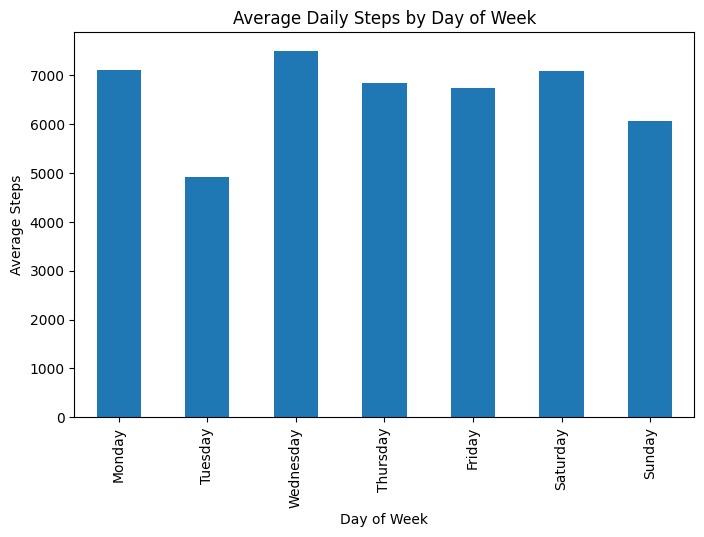

In [36]:
weekday_steps.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Daily Steps by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Steps")

plt.show()

### 4.7 Relationship Between Steps and Calories Burned

The relationship between daily steps and calories burned was examined to determine whether increased activity is associated with higher calorie expenditure.

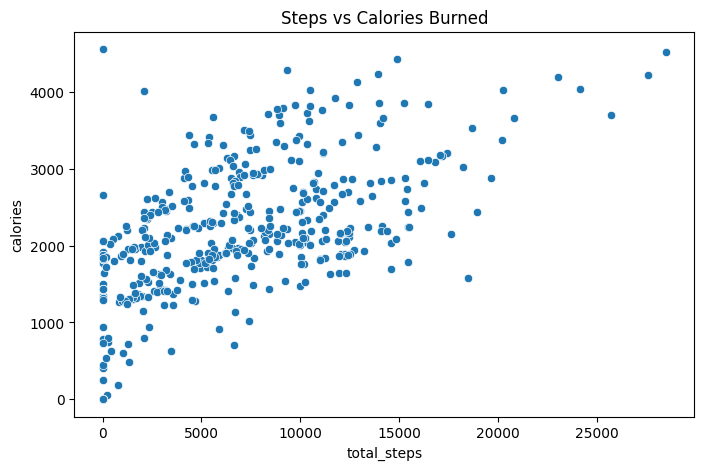

In [37]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=daily_activity,
    x="total_steps",
    y="calories"
)

plt.title("Steps vs Calories Burned")

plt.show()

### 4.8 User Activity Classification

Users were classified into activity levels based on their daily step counts.

In [38]:
def classify_activity(steps):
    if steps < 5000:
        return "Inactive"
    elif steps < 7500:
        return "Low Active"
    elif steps < 10000:
        return "Somewhat Active"
    else:
        return "Active"

daily_activity["activity_level"] = (
    daily_activity["total_steps"]
    .apply(classify_activity)
)

daily_activity["activity_level"].value_counts()

,count
activity_level,
Inactive,197
Active,127
Low Active,83
Somewhat Active,50


Most users were classified as inactive (197 records), while only 127 records were considered active. This suggests that many users are not consistently meeting recommended daily activity levels.

### 4.9 Interpretation of Findings

On average, Fitbit users recorded 6,547 steps and traveled approximately 4.66 kilometers per day. This activity level falls below the commonly recommended target of 10,000 daily steps associated with improved health and fitness outcomes.

Users spent an average of 995 sedentary minutes per day, indicating that a substantial portion of their daily routine involved inactive behavior. This suggests that sedentary behavior remains a significant challenge for many users.

The average daily calorie expenditure was approximately 2,189 calories. However, calorie burn can vary depending on factors such as age, body weight, metabolism, exercise intensity, and lifestyle habits.

Overall, the findings suggest that many users maintain moderate activity levels but could benefit from increased daily movement and reduced sedentary time. These insights provide opportunities for Bellabeat to encourage healthier habits through personalized reminders, activity goals, and wellness challenges.
***

# STEP 5: SHARE

### Key Findings

Based on the analysis, several important trends were identified:

1. Fitbit users recorded an average of 6,547 steps per day, which is below the commonly recommended goal of 10,000 daily steps.

2. Users spent an average of 995 minutes per day in sedentary activities, indicating that inactive behavior occupies a significant portion of daily routines.

3. A positive relationship was observed between daily steps and calories burned, suggesting that increased physical activity contributes to higher energy expenditure.

4. Most users were classified as inactive, while a smaller proportion consistently achieved recommended activity levels.

These findings indicate opportunities for Bellabeat to support users in developing healthier and more active lifestyles.
***

# STEP 6: ACT

### Recommendations

Based on the findings, the following recommendations are proposed for Bellabeat:

#### 1. Personalized Activity Reminders

Implement personalized notifications that encourage users to move throughout the day and reduce prolonged sedentary behavior.

#### 2. Goal-Based Wellness Challenges

Create daily and weekly step challenges to motivate users to achieve recommended activity levels and build healthy habits.

#### 3. Activity Progress Tracking

Provide visual progress dashboards and milestone rewards to help users monitor their fitness journey and maintain engagement.

#### 4. Target Inactive Users

Develop targeted wellness campaigns for users with low activity levels by offering educational content, fitness tips, and achievable activity goals.

### Final Conclusion

The analysis revealed that many Fitbit users maintain moderate activity levels but spend a substantial amount of time inactive. By encouraging increased movement, reducing sedentary behavior, and promoting consistent activity habits, Bellabeat can improve user engagement and better support its mission of helping women build healthier lifestyles.